In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
batch_size = 128
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST(root='../data', train=True, transform=transform, download=True)
# train_dataset = datasets.FashionMNIST(root='../data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [4]:
latent_dim = 64

class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim= latent_dim):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        # Latent space
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 128)
        self.fc4 = nn.Linear(128, 256)
        self.fc5 = nn.Linear(256, input_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        h = self.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.relu(self.fc3(z))
        h = self.relu(self.fc4(h))
        x = self.sigmoid(self.fc5(h))
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_constructed = self.decode(z)
        return x_constructed, mu, logvar

In [5]:
def vae_loss(x, x_reconstructed, mu, logvar):
    recon_loss = F.mse_loss(x_reconstructed, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

In [ ]:
epochs = 5
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        # Flatten the image so it matches the linear encoder input.
        data = data.view(-1, 784).to(device)
        optimizer.zero_grad()
        x_reconstructed, mu, logvar = model(data)
        loss = vae_loss(data, x_reconstructed, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    # Average over the full dataset for a clearer epoch-level loss.
    avg_loss = train_loss / len(train_loader.dataset)

    print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

Epoch 1, Loss: 52.3723
Epoch 2, Loss: 42.9407
Epoch 3, Loss: 37.3423
Epoch 4, Loss: 34.2891
Epoch 5, Loss: 32.8374


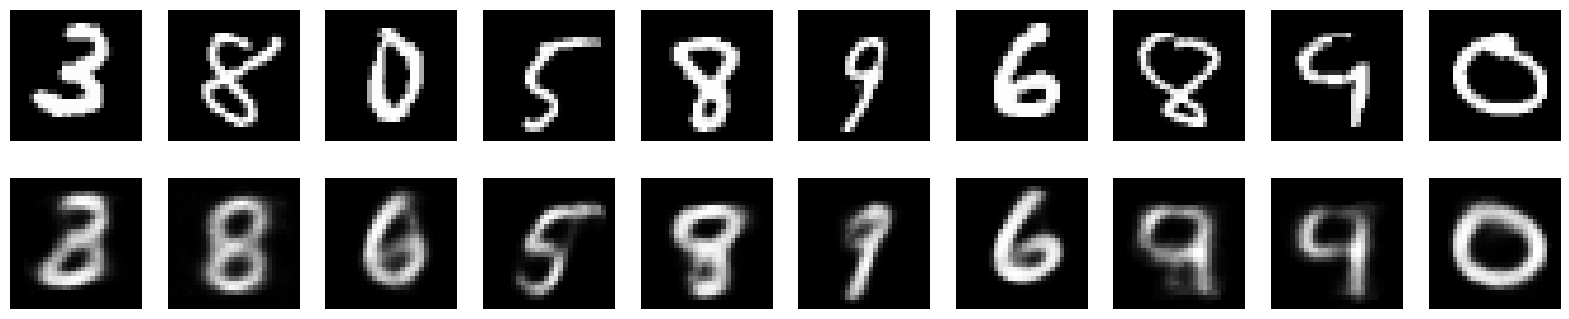

In [7]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784).to(device)
    x_reconstructed, _, _ = model(x)
    x = x.cpu().view(-1, 1, 28, 28)
    x_reconstructed = x_reconstructed.cpu().view(-1, 1, 28, 28)

    n = 10
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.axis('off')
        plt.imshow(x[i].squeeze(), cmap='gray')


        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.axis('off')
        plt.imshow(x_reconstructed[i].squeeze(), cmap='gray')

    plt.show()

In [8]:
model.eval()

latents = []
labels = []

with torch.no_grad():
    # Collect latent vectors for a quick look at the learned space.
    for batch in train_loader:
        x, y = batch
        x = x.view(-1, 28 * 28).to(device)
        mu, logvar = model.encode(x)
        z = model.reparameterize(mu, logvar)
        latents.append(z.cpu().numpy())
        labels.append(y.numpy())

latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

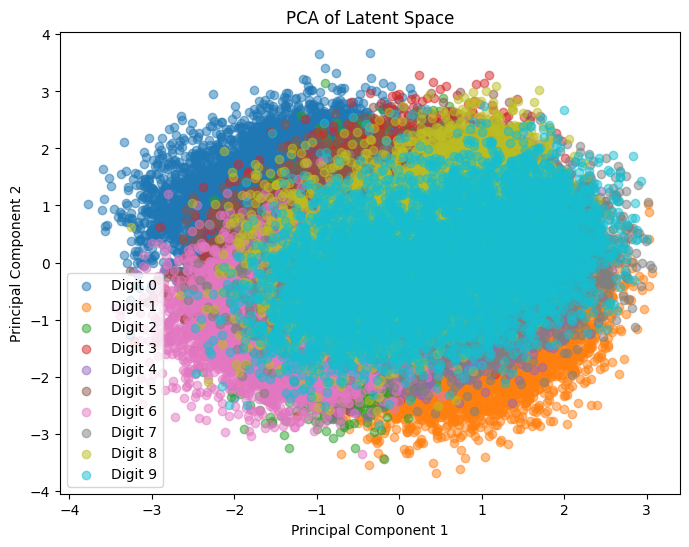

In [9]:
from sklearn.decomposition import PCA

latent_dim = latents.shape[1]

z = latents.detach().cpu().numpy() if torch.is_tensor(latents) else latents
y = labels.detach().cpu().numpy() if torch.is_tensor(labels) else labels


if latent_dim == 1 :
    plt.figure(figsize=(8, 6))
    for digit in range(10):
        plt.hist(
            z[y == digit],
            bins=30,
            alpha=0.5,
            label=f"Digit {digit}"
        )
    plt.title("Distribution of 1D Latent Space")
    plt.xlabel("Latent Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

elif latent_dim == 2:
    plt.figure(figsize=(8, 6))
    for digit in range(10):
        plt.scatter(
            z[y == digit, 0],
            z[y == digit, 1],
            alpha=0.5,
            label=f"Digit {digit}"
        )
    plt.title("2D Latent Space Visualization")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.legend()
    plt.show()

elif latent_dim == 3:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    for digit in range(10):
        ax.scatter(
            z[y == digit, 0],
            z[y == digit, 1],
            z[y == digit, 2],
            cmap='tab10', s=5,
            alpha=0.7,
            label=f"Digit {digit}"
        )
    ax.set_title("3D Latent Space Visualization")
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_zlabel("z3")
    ax.legend()
    plt.show()

else:
    # Use PCA to project larger latent spaces into 2D for plotting.
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z)

    plt.figure(figsize=(8, 6))
    for digit in range(10):
        plt.scatter(
            z_2d[y == digit, 0],
            z_2d[y == digit, 1],
            alpha=0.5,
            label=f"Digit {digit}"
        )
    plt.title("PCA of Latent Space")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.show()

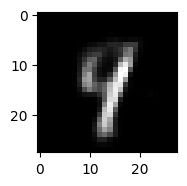

In [ ]:
with torch.no_grad():
    # Sample random latent vectors and decode them into images.
    z = torch.randn(64, latent_dim).to(device)
    generated = model.decode(z).cpu().view(-1, 1, 28, 28)

    n = 1
    plt.figure(figsize=(20, 4))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.show()